# Regression - Example demonstrating main principles that always repeat (in one form or another)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import root_mean_squared_error

## Loading Data

In [2]:
# Create a toy regression dataset
X, y = make_regression(n_samples=1000, n_features=5, noise=20, random_state=42)

In [3]:
df = pd.DataFrame(X, columns=[f"Feature_{i}" for i in range(X.shape[1])])
df["Target"] = y

In [4]:
df.head()

,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Target
0,2.056544,0.606851,0.482688,-1.130888,0.420094,66.595254
1,-0.799192,-0.645964,-0.182896,-0.482744,1.374876,-61.659436
2,1.076007,-0.796026,-0.751969,0.021312,-0.319054,-49.947499
3,-0.103255,-0.828497,1.489863,-1.643189,-1.600904,-79.939739
4,-2.063403,0.503252,-0.645572,-0.317350,-1.661083,-80.651266


## Train, Validation, and Test Set

In [5]:
X = df.drop(columns=["Target"])
y = df["Target"]

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=40)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.3, random_state=36)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (560, 5)
Validation size: (240, 5)
Test size: (200, 5)


## EDA

Text(0.5, 1.0, 'Distribution of Target Variable')

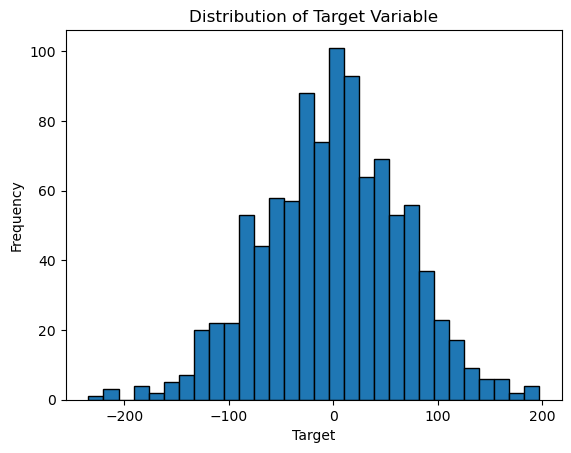

In [6]:
plt.hist(y, bins=30, edgecolor="black")
plt.xlabel("Target")
plt.ylabel("Frequency")
plt.title("Distribution of Target Variable")

In [7]:
corr = df.corr(numeric_only=True)["Target"].sort_values(ascending=False)
print("Correlation with target:\n", corr)

Correlation with target:
 Target       1.000000
Feature_1    0.695540
Feature_0    0.376001
Feature_3    0.357873
Feature_4    0.285183
Feature_2    0.279431
Name: Target, dtype: float64


## Training models

In [8]:
# Linear regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
lin_reg_pred = lin_reg.predict(X_val)

# Decision tree
tree_reg = DecisionTreeRegressor(random_state=42)
hyperparams = {
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

tree_reg_gs = GridSearchCV(tree_reg, hyperparams, scoring="neg_mean_squared_error", cv=5, n_jobs=-1)
tree_reg_gs.fit(X_train, y_train)

tree_reg_gs_pred = tree_reg_gs.predict(X_val) 

In [10]:
# print(tree_reg_gs.best_params_)
# pd.DataFrame(tree_reg_gs.cv_results_)

In [11]:
lr_rmse = root_mean_squared_error(lin_reg_pred, y_val)
tree_rmse = root_mean_squared_error(tree_reg_gs_pred, y_val)

print("RMSE LR:", lr_rmse, "\nRMSE Tree:", tree_rmse)

RMSE LR: 20.725243967021463 
RMSE Tree: 41.18026776055872


## Evaluation on test data

In [12]:
lr_final = lin_reg.fit(X_train_val, y_train_val)

In [13]:
lr_test_pred = lr_final.predict(X_test)

lr_rmse_test = root_mean_squared_error(lr_test_pred, y_test)
print(lr_rmse_test)

20.505749184566383


## Retraining the model on all data and saving it

In [14]:
lr_finished = lin_reg.fit(X, y)

In [15]:
import joblib

In [16]:
joblib.dump(lr_finished, 'lr_finished.pkl')
print("Model saved!")
loaded_model = joblib.load('lr_finished.pkl')
print("Model loaded!")

Model saved!
Model loaded!


In [17]:
predictions = loaded_model.predict(X_test.iloc[:5, :])
print(predictions)
print(y_test.iloc[:5])


[ 92.36333777  48.04244782 -87.03395226 -28.83554399  84.49223751]
204    102.987469
71      47.091028
594   -105.747326
672    -21.903111
14     116.131344
Name: Target, dtype: float64


## Questions
1. Explain what the code does. What are the main steps?
2. What does this code do?
   
print(tree_reg_gs.best_params_)

pd.DataFrame(tree_reg_gs.cv_results_)

3. Try to add a third model (example, random forest) in the modelling flow.